# FRM Parte I, libro 1: Fundamentos de la gestión de riesgos

Casos trabajados con datos chilenos para los temas centrales del libro. Cada caso presenta el concepto, lo aplica a datos reales, interpreta el resultado y resume lo que suele evaluarse en el examen.

| Caso | Tema del programa |
|---|---|
| 1 | CAPM y la línea del mercado de valores |
| 2 | Medidas de desempeño ajustadas por riesgo |
| 3 | Teoría de precios por arbitraje y modelos multifactoriales |
| 4 | Cómo gestionan el riesgo las empresas: la decisión de cobertura |
| 5 | Lecciones de desastres financieros: apalancamiento y liquidez |

Las fórmulas están en el módulo `frm` del paquete, validadas con pruebas contra ejemplos de los textos de referencia.

## Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from dsaplicado import bcch, datos, frm, portafolio as pf
from dsaplicado.graficos import COLORES, NEUTRO, TINTA_SECUNDARIA, TINTA_TENUE, aplicar_estilo, eje_porcentaje

aplicar_estilo()
pd.set_option("display.float_format", "{:.3f}".format)
RAIZ = datos.raiz_repositorio()
FIGURAS = RAIZ / "05_FRM" / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

precios = datos.cargar_precios(RAIZ / "datos" / "precios_ipsa.csv", {**datos.ACCIONES_IPSA, **datos.BENCHMARK_IPSA},
                               "2019-01-01", "2026-09-01").ffill()
acciones = list(datos.ACCIONES_IPSA.values())
retornos = pf.retornos_simples(precios).dropna()
retornos["Cartera pesos iguales"] = retornos[acciones].mean(axis=1)
mercado = retornos["ETF IPSA"]

tpm = datos.cargar_indicador(RAIZ / "datos" / "tpm_historico.csv", "tpm", range(2001, 2027))
tpm = tpm.mask(tpm < 0.25).ffill() / 100
rf_anual = float(tpm.loc[retornos.index[0]:retornos.index[-1]].mean())
rf_diario = ((1 + tpm) ** (1 / 252) - 1).reindex(retornos.index).ffill()
print(f"{len(retornos):,} días, de {retornos.index[0]:%m-%Y} a {retornos.index[-1]:%m-%Y}. TPM promedio: {rf_anual:.2%}")

1,908 días, de 01-2019 a 08-2026. TPM promedio: 4.90%


## Caso 1. CAPM y la línea del mercado de valores

**Concepto.** El CAPM dice que el retorno esperado de un activo depende solo de su riesgo sistemático, medido por la beta:

$$E[R_i] = R_f + \beta_i \,(E[R_m] - R_f), \qquad \beta_i = \frac{\text{Cov}(R_i, R_m)}{\text{Var}(R_m)}$$

La línea del mercado de valores (SML) grafica esa relación. Un activo sobre la línea rindió más de lo que su riesgo justificaba: tiene alfa positivo.

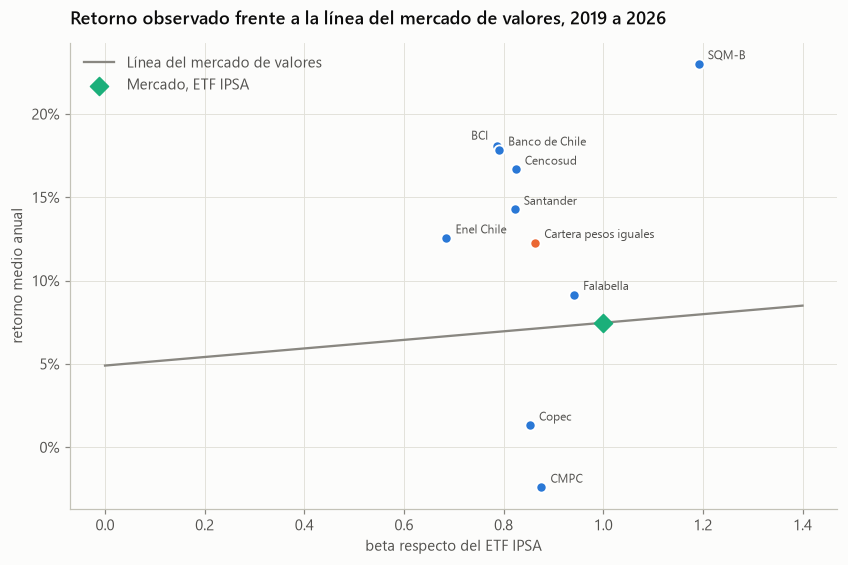

,beta,retorno_anual,retorno_capm,alfa_anual,r2
Enel Chile,0.685,0.126,0.067,0.059,0.228
BCI,0.787,0.181,0.069,0.112,0.330
Banco de Chile,0.791,0.178,0.069,0.109,0.400
Santander,0.822,0.143,0.070,0.073,0.416
Cencosud,0.824,0.167,0.070,0.097,0.297
Copec,0.853,0.013,0.071,-0.057,0.339
Cartera pesos iguales,0.863,0.123,0.071,0.052,0.670
CMPC,0.876,-0.024,0.072,-0.095,0.310
Falabella,0.941,0.092,0.073,0.019,0.363
SQM-B,1.191,0.230,0.080,0.150,0.331


In [2]:
capm = pf.beta_capm(retornos[acciones + ["Cartera pesos iguales"]], mercado, rf_diario)
retorno_mercado = mercado.mean() * 252
capm["retorno_anual"] = retornos[capm.index].mean() * 252
capm["retorno_capm"] = rf_anual + capm["beta"] * (retorno_mercado - rf_anual)
capm = capm.sort_values("beta")

fig, ax = plt.subplots(figsize=(9, 5.5))
betas = np.linspace(0, 1.4, 50)
ax.plot(betas, rf_anual + betas * (retorno_mercado - rf_anual), color=TINTA_TENUE, linewidth=1.5, label="Línea del mercado de valores")
for nombre, fila in capm.iterrows():
    color = COLORES[1] if nombre == "Cartera pesos iguales" else COLORES[0]
    ax.scatter(fila["beta"], fila["retorno_anual"], s=45, color=color, edgecolor="white", linewidth=1.2, zorder=3)
    dx, dy, ha = {"BCI": (-6, 4, "right")}.get(nombre, (6, 3, "left"))
    ax.annotate(nombre, (fila["beta"], fila["retorno_anual"]), xytext=(dx, dy), textcoords="offset points", fontsize=8,
                ha=ha, color=TINTA_SECUNDARIA)
ax.scatter(1, retorno_mercado, s=70, marker="D", color=COLORES[2], zorder=3, label="Mercado, ETF IPSA")
eje_porcentaje(ax)
ax.set_xlabel("beta respecto del ETF IPSA")
ax.set_ylabel("retorno medio anual")
ax.set_title("Retorno observado frente a la línea del mercado de valores, 2019 a 2026")
ax.legend(loc="upper left")
fig.savefig(FIGURAS / "linea_mercado_valores.png", bbox_inches="tight")
plt.show()
capm[["beta", "retorno_anual", "retorno_capm", "alfa_anual", "r2"]]

**Lectura.**

- **Casi todas las acciones quedaron sobre la línea.** Los bancos y SQM rindieron entre 14% y 23% al año, cuando el CAPM predecía cerca de 7% para sus betas.
- **Esto no contradice necesariamente al CAPM.** Es un período corto y la muestra tiene sesgo de supervivencia: son acciones que hoy siguen en el IPSA. El alfa realizado mide suerte y habilidad mezcladas.
- **La cartera de pesos iguales tiene un R cuadrado de 0,67,** muy superior al de cada acción, que va de 0,23 a 0,42. Diversificar elimina gran parte del riesgo idiosincrático.

**Para el examen.**

- La beta mide solo el riesgo que no se puede diversificar. El riesgo idiosincrático, la parte que la beta no explica, no tiene premio en el CAPM.
- La SML usa la beta en el eje horizontal; la línea del mercado de capitales (CML) usa la volatilidad total y solo vale para carteras eficientes.
- Supuestos del CAPM: inversionistas con aversión al riesgo que optimizan media y varianza, un solo período, préstamos y créditos a la tasa libre de riesgo, sin impuestos ni costos de transacción, y expectativas homogéneas.

## Caso 2. Medidas de desempeño ajustadas por riesgo

**Concepto.**

| Medida | Fórmula | Riesgo que usa | Cuándo sirve |
|---|---|---|---|
| Sharpe | $(R_p - R_f)/\sigma_p$ | total | cartera que es toda la riqueza del inversionista |
| Treynor | $(R_p - R_f)/\beta_p$ | sistemático | cartera que es parte de una cartera diversificada |
| Alfa de Jensen | $R_p - [R_f + \beta_p(R_m - R_f)]$ | sistemático | medir el retorno por sobre el CAPM |
| Índice de información | $(R_p - R_b)/\text{TE}$ | relativo a la referencia | gestores activos, con TE el error de seguimiento |
| Sortino | $(R_p - R_{\text{objetivo}})/\sigma_{\text{baja}}$ | solo caídas | inversionistas que temen las pérdidas, no la volatilidad |

In [3]:
filas = {}
for nombre in acciones + ["Cartera pesos iguales", "ETF IPSA"]:
    r = retornos[nombre]
    beta = 1.0 if nombre == "ETF IPSA" else capm.loc[nombre, "beta"]
    retorno, volatilidad = r.mean() * 252, r.std() * np.sqrt(252)
    filas[nombre] = {
        "Sharpe": frm.indice_sharpe(retorno, volatilidad, rf_anual),
        "Treynor": frm.indice_treynor(retorno, beta, rf_anual),
        "alfa de Jensen": frm.alfa_jensen(retorno, beta, rf_anual, retorno_mercado),
        "índice de información": np.nan if nombre == "ETF IPSA" else frm.indice_informacion(r, mercado),
        "Sortino": frm.indice_sortino(r, rf_anual),
    }
desempeno = pd.DataFrame(filas).T.sort_values("Sharpe", ascending=False)
desempeno

,Sharpe,Treynor,alfa de Jensen,índice de información,Sortino
Banco de Chile,0.479,0.163,0.109,0.485,0.718
BCI,0.446,0.168,0.112,0.431,0.650
SQM-B,0.405,0.152,0.150,0.422,0.600
Cencosud,0.361,0.143,0.097,0.334,0.531
Santander,0.341,0.114,0.073,0.318,0.485
Cartera pesos iguales,0.324,0.085,0.052,0.359,0.458
Enel Chile,0.248,0.112,0.059,0.182,0.361
Falabella,0.126,0.045,0.018,0.063,0.183
ETF IPSA,0.119,0.026,0.000,NaN,0.165
Copec,-0.113,-0.042,-0.058,-0.237,-0.164


In [4]:
rankings = desempeno.rank(ascending=False)
print("Posición de cada activo según cada medida, 1 es el mejor:")
rankings.astype("Int64")

Posición de cada activo según cada medida, 1 es el mejor:


,Sharpe,Treynor,alfa de Jensen,índice de información,Sortino
Banco de Chile,1,2,3,1,1
BCI,2,1,2,2,2
SQM-B,3,3,1,3,3
Cencosud,4,4,4,5,4
Santander,5,5,5,6,5
Cartera pesos iguales,6,7,7,4,6
Enel Chile,7,6,6,7,7
Falabella,8,8,8,8,8
ETF IPSA,9,9,9,<NA>,9
Copec,10,10,10,9,10


**Lectura.**

- **Las medidas coinciden en lo grueso.** Banco de Chile, BCI y SQM ocupan los primeros lugares, y Copec y CMPC los últimos, en casi todas.
- **SQM muestra la diferencia entre riesgo total y sistemático.** Es la primera según el alfa de Jensen, pero la tercera según Sharpe, porque su volatilidad total es la más alta.
- **La cartera diversificada sube en el índice de información.** Es la sexta según Sharpe, pero la cuarta según el índice de información, porque su error de seguimiento frente al IPSA es bajo.

**Para el examen.**

- Sharpe y Treynor ordenan igual a las carteras bien diversificadas, porque en ellas casi todo el riesgo es sistemático. Difieren en activos individuales, donde el riesgo idiosincrático pesa.
- El alfa de Jensen está en unidades de retorno, no de retorno por riesgo, así que no sirve para comparar carteras con distinto apalancamiento.
- El índice de información es la medida natural para evaluar a un gestor contra su índice de referencia.

## Caso 3. Modelos multifactoriales

**Concepto.** La teoría de precios por arbitraje (APT) generaliza el CAPM: el retorno depende de varios factores de riesgo sistemático, cada uno con su propia sensibilidad.

$$R_i = \alpha_i + \beta_{i,1} F_1 + \beta_{i,2} F_2 + \dots + \varepsilon_i$$

Para la economía chilena, tres factores naturales son el mercado local, el tipo de cambio y el precio del cobre, su principal exportación. Se usan retornos mensuales.

In [5]:
cobre = datos.cargar_indicador(RAIZ / "datos" / "libra_cobre_historico.csv", "libra_cobre", range(2012, 2027))
dolar = datos.cargar_indicador(RAIZ / "datos" / "dolar_historico.csv", "dolar", range(2000, 2027))
mensual = precios.resample("ME").last().pct_change().dropna()
factores = pd.DataFrame({
    "mercado": mensual["ETF IPSA"],
    "dólar": dolar.resample("ME").last().pct_change(),
    "cobre": cobre.resample("ME").last().pct_change(),
}).dropna()
mensual = mensual.loc[factores.index]
print(f"{len(factores)} meses. Correlación entre factores:")
print(factores.corr().round(2).to_string())

resultados = {}
for accion in acciones:
    modelo = sm.OLS(mensual[accion], sm.add_constant(factores)).fit()
    resultados[accion] = {**{f"beta {f}": modelo.params[f] for f in factores},
                          **{f"t {f}": modelo.tvalues[f] for f in factores}, "R2": modelo.rsquared}
multifactor = pd.DataFrame(resultados).T
multifactor

91 meses. Correlación entre factores:
         mercado  dólar  cobre
mercado    1.000 -0.340  0.360
dólar     -0.340  1.000 -0.630
cobre      0.360 -0.630  1.000


,beta mercado,beta dólar,beta cobre,t mercado,t dólar,t cobre,R2
BCI,0.945,-0.038,-0.145,8.342,-0.213,-1.179,0.465
Santander,1.007,0.185,0.007,9.902,1.162,0.059,0.551
Banco de Chile,0.755,-0.191,-0.221,7.298,-1.178,-1.964,0.410
Cencosud,0.949,0.244,0.096,7.078,1.161,0.660,0.396
CMPC,0.514,-0.131,-0.147,3.739,-0.607,-0.981,0.155
Copec,0.781,-0.217,-0.015,6.457,-1.143,-0.112,0.398
Enel Chile,0.733,-0.320,-0.222,4.887,-1.361,-1.363,0.257
Falabella,1.274,0.427,0.546,10.046,2.148,3.965,0.640
SQM-B,1.293,0.116,-0.110,6.201,0.355,-0.483,0.320


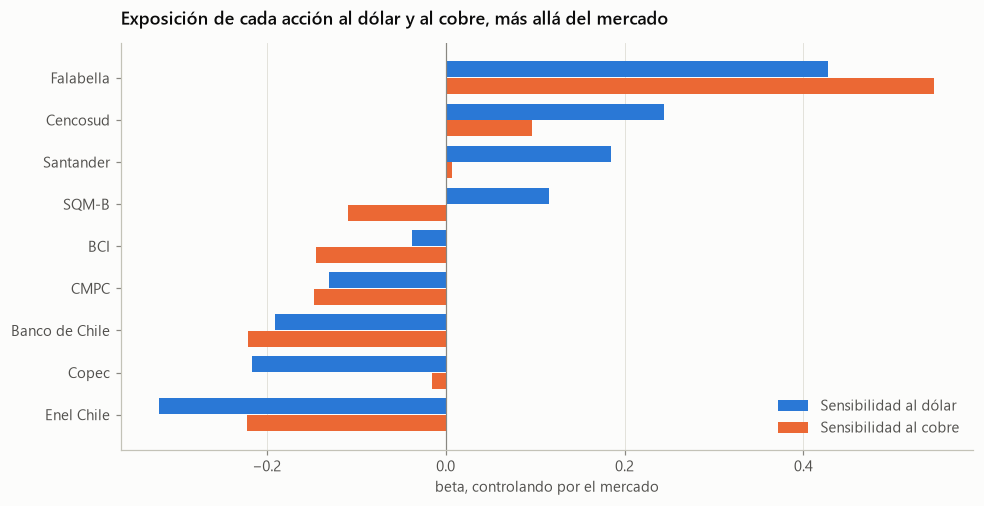

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.8))
y = np.arange(len(acciones))
orden = multifactor.sort_values("beta dólar").index
ax.barh(y + 0.2, multifactor.loc[orden, "beta dólar"], height=0.38, color=COLORES[0], label="Sensibilidad al dólar")
ax.barh(y - 0.2, multifactor.loc[orden, "beta cobre"], height=0.38, color=COLORES[1], label="Sensibilidad al cobre")
ax.set_yticks(y, orden)
ax.axvline(0, color=TINTA_TENUE, linewidth=0.8)
ax.set_xlabel("beta, controlando por el mercado")
ax.set_title("Exposición de cada acción al dólar y al cobre, más allá del mercado")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
plt.show()

**Lectura.**

- **El mercado explica casi todo.** Su beta es significativa en las nueve acciones, con estadísticos t entre 3,7 y 10.
- **El dólar y el cobre agregan poco.** Solo Falabella tiene sensibilidades significativas a ambos, positivas, y Banco de Chile al cobre queda en el límite. El índice IPSA ya incorpora buena parte del efecto del dólar y del cobre.
- **Multicolinealidad.** El dólar y el cobre tienen una correlación de -0,63: cuando el cobre sube, el peso se aprecia. Con factores tan correlacionados, las betas individuales se estiman con mucho error.

**Para el examen.**

- La APT no dice cuáles son los factores; solo exige que no haya oportunidades de arbitraje. El CAPM es un caso particular con un solo factor.
- Las betas multifactoriales permiten cubrir un riesgo específico, como el cambiario, sin cubrir el resto.
- El modelo de Fama y French agrega a la beta de mercado los factores de tamaño y de valor.

## Caso 4. La decisión de cobertura: un exportador chileno

**Concepto.** Una empresa que vende en dólares y paga costos en pesos está expuesta al tipo de cambio. Puede fijar hoy el tipo de cambio de sus ventas futuras con un contrato forward. El forward se calcula por paridad cubierta de tasas:

$$F = S \cdot \frac{1 + i_{\text{CLP}} \cdot \tfrac{d}{360}}{1 + i_{\text{USD}} \cdot \tfrac{d}{360}}$$

Se simula un exportador que cada mes vende US$1 millón con pago a 90 días, y se compara no cubrirse con cubrir todo con forwards, entre 2010 y 2026.

In [7]:
swap = bcch.cargar_series({"F022.SPC.TPR.D090.NO.Z.D": "0.25"}, None, None, RAIZ / "datos" / "bcch" / "swap_camara_pesos.csv")["0.25"] / 100
tbill = datos.cargar_fred("DTB3", RAIZ / "datos" / "fred") / 100
mes = pd.DataFrame({"spot": dolar.resample("ME").last(), "i_clp": swap.resample("ME").last(),
                    "i_usd": tbill.resample("ME").last()}).loc["2010":].dropna()
mes["forward_3m"] = mes["spot"] * (1 + mes["i_clp"] * 90 / 360) / (1 + mes["i_usd"] * 90 / 360)
mes["spot_en_3m"] = mes["spot"].shift(-3)
mes = mes.dropna()
mes["sin_cobertura"] = mes["spot_en_3m"] / mes["spot"] - 1   # pesos recibidos frente al tipo de cambio del día de la venta
mes["con_cobertura"] = mes["forward_3m"] / mes["spot"] - 1

resumen = pd.DataFrame({
    "promedio": mes[["sin_cobertura", "con_cobertura"]].mean(),
    "desviación estándar": mes[["sin_cobertura", "con_cobertura"]].std(),
    "peor mes": mes[["sin_cobertura", "con_cobertura"]].min(),
    "mejor mes": mes[["sin_cobertura", "con_cobertura"]].max(),
})
resumen.style.format("{:.2%}")

,promedio,desviación estándar,peor mes,mejor mes
sin_cobertura,1.02%,5.49%,-14.27%,16.87%
con_cobertura,0.68%,0.54%,-0.02%,2.06%


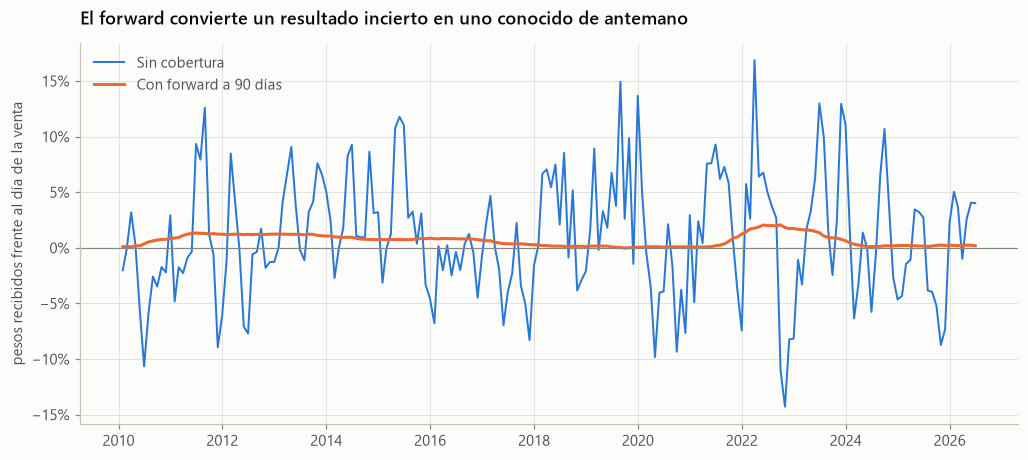

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(mes.index, mes["sin_cobertura"], color=COLORES[0], linewidth=1.3, label="Sin cobertura")
ax.plot(mes.index, mes["con_cobertura"], color=COLORES[1], linewidth=2, label="Con forward a 90 días")
ax.axhline(0, color=TINTA_TENUE, linewidth=0.8)
eje_porcentaje(ax)
ax.set_ylabel("pesos recibidos frente al día de la venta")
ax.set_title("El forward convierte un resultado incierto en uno conocido de antemano")
ax.legend(loc="upper left")
fig.savefig(FIGURAS / "cobertura_exportador.png", bbox_inches="tight")
plt.show()

**Lectura.**

- **Sin cobertura, el resultado varía mucho.** La desviación estándar trimestral es de 5,5%, con meses en que el exportador recibió 14% menos o 17% más pesos que el día de la venta.
- **Con cobertura, el resultado se conoce de antemano.** La desviación cae a 0,5%, y solo refleja el cambio en el diferencial de tasas entre Chile y Estados Unidos.
- **En promedio, no cubrirse rindió algo más:** 1,02% frente a 0,68% por trimestre, porque el peso se depreció en el período. Pero nadie sabía de antemano que eso ocurriría.

**Para el examen.**

- Cubrirse no busca ganar dinero, sino reducir la variabilidad. En promedio, el costo o beneficio de la cobertura es el diferencial de tasas.
- Argumentos a favor de cubrirse: reduce la probabilidad de problemas financieros, los costos de quiebra y los impuestos esperados cuando la función de impuestos es convexa, y facilita planificar.
- Argumentos en contra: según Modigliani y Miller los accionistas pueden diversificar por sí mismos, la cobertura tiene costos, y si los competidores no se cubren, cubrirse puede aumentar el riesgo relativo.
- Riesgos de la cobertura: riesgo de base, riesgo de liquidez por llamados de margen y cobertura de flujos inciertos.

## Caso 5. Lecciones de desastres financieros: el apalancamiento

**Concepto.** Con apalancamiento $L$, el retorno del patrimonio es aproximadamente

$$R_{\text{patrimonio}} = L \cdot R_{\text{activos}} - (L - 1) \cdot r_{\text{financiamiento}}$$

Long-Term Capital Management (LTCM) operaba en 1998 con activos cercanos a 25 veces su patrimonio. Con ese nivel, una caída de 4% en el valor de los activos elimina todo el capital.

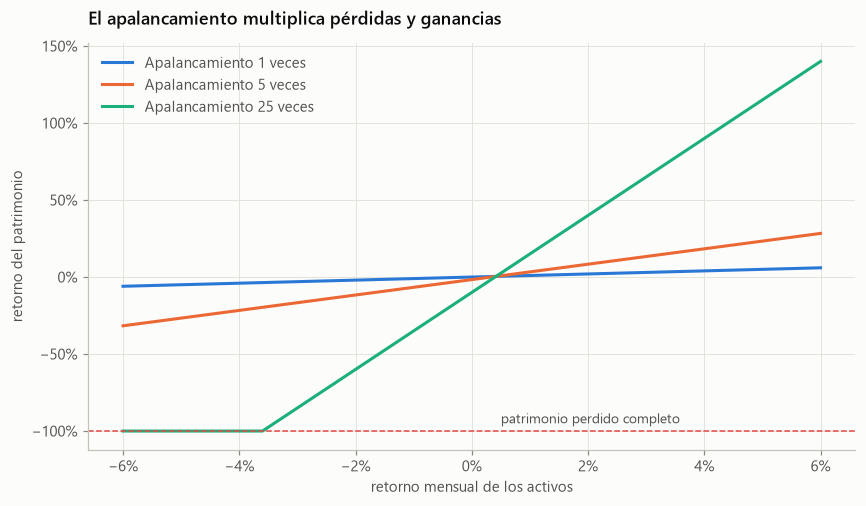

,caída de activos que elimina el patrimonio
2,49.8%
5,19.7%
10,9.6%
25,3.6%
50,1.6%


In [9]:
retorno_activos = np.linspace(-0.06, 0.06, 121)
costo_financiamiento = 0.05 / 12   # un mes
fig, ax = plt.subplots(figsize=(9, 4.8))
for k, apalancamiento in enumerate([1, 5, 25]):
    retorno_patrimonio = apalancamiento * retorno_activos - (apalancamiento - 1) * costo_financiamiento
    ax.plot(retorno_activos, retorno_patrimonio.clip(-1), color=COLORES[k], linewidth=2, label=f"Apalancamiento {apalancamiento} veces")
ax.axhline(-1, color=COLORES[7], linewidth=1, linestyle="--")
ax.annotate("patrimonio perdido completo", (0.005, -0.95), fontsize=9, color=TINTA_SECUNDARIA)
eje_porcentaje(ax, "x")
eje_porcentaje(ax, "y")
ax.set_xlabel("retorno mensual de los activos")
ax.set_ylabel("retorno del patrimonio")
ax.set_title("El apalancamiento multiplica pérdidas y ganancias")
ax.legend(loc="upper left")
plt.show()

perdida_que_quiebra = pd.Series({L: (1 - (L - 1) * costo_financiamiento) / L for L in [2, 5, 10, 25, 50]},
                                name="caída de activos que elimina el patrimonio")
perdida_que_quiebra.to_frame().style.format("{:.1%}")

Casi todos los desastres del programa combinan apalancamiento, iliquidez y fallas de control:

| Caso | Qué pasó | Lección |
|---|---|---|
| LTCM, 1998 | Posiciones de convergencia muy apalancadas; la crisis rusa amplió los spreads en vez de cerrarlos | Riesgo de modelo, de liquidez y de concentración: las correlaciones suben en crisis |
| Metallgesellschaft, 1993 | Cubría contratos de largo plazo con futuros de corto plazo renovados; la caída del petróleo generó enormes llamados de margen | Una cobertura correcta en valor puede fallar por flujo de caja |
| Barings, 1995 | Un solo operador ocultó pérdidas porque controlaba a la vez la operación y su registro | Separación de funciones entre la mesa y el back office |
| Société Générale, 2008 | Posiciones no autorizadas ocultas con operaciones ficticias | Controles que respondan a las alertas, no solo que existan |
| London Whale, JPMorgan, 2012 | Una cobertura de crédito creció hasta ser una apuesta; se cambió el modelo de VaR y bajó el riesgo reportado | Gobierno de modelos y validación independiente |
| Crisis financiera, 2007 a 2009 | Hipotecas de baja calidad titulizadas, apalancamiento y dependencia del financiamiento de corto plazo | Riesgo sistémico, incentivos mal alineados y riesgo de liquidez de financiamiento |

**Para el examen.** En estos casos se pregunta qué tipo de riesgo falló: de mercado, de liquidez de activos, de liquidez de financiamiento, operacional o de modelo, y qué control lo habría evitado.